In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
#Load data
train_df = pd.read_csv('data/train.csv')
train_df.set_index(train_df['id'], inplace=True)
train_df.drop(['id'], axis=1,inplace=True)
train_df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [30]:
#Load test data
test_df = pd.read_csv('data/test.csv')
test_df.set_index(test_df['id'], inplace=True)
test_df.drop(['id'], axis=1,inplace=True)
test_df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
id,,,,,,,,,,,,,
630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


## EDA

In [31]:
#Basic Description
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,630000.0,54.136706,8.256301,29.0,48.0,54.0,60.0,77.0
Sex,630000.0,0.714735,0.451541,0.0,0.0,1.0,1.0,1.0
Chest pain type,630000.0,3.312752,0.851615,1.0,3.0,4.0,4.0,4.0
BP,630000.0,130.497433,14.975802,94.0,120.0,130.0,140.0,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,223.0,243.0,269.0,564.0
FBS over 120,630000.0,0.079987,0.271274,0.0,0.0,0.0,0.0,1.0
EKG results,630000.0,0.981660,0.998783,0.0,0.0,0.0,2.0,2.0
Max HR,630000.0,152.816763,19.112927,71.0,142.0,157.0,166.0,202.0
Exercise angina,630000.0,0.273725,0.445870,0.0,0.0,0.0,1.0,1.0
ST depression,630000.0,0.716028,0.948472,0.0,0.0,0.1,1.4,6.2


In [32]:
#Basic Description - target values
train_df['Heart Disease'].value_counts()/len(train_df)

#Target appears to be fairly balanced - 55% - 45% for Absence - Presence

Heart Disease
Absence     0.55166
Presence    0.44834
Name: count, dtype: float64

In [33]:
#Basic Description - nulls
train_df.isnull().sum()

#No null values!

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [34]:
feat_num = [
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression',
    'Number of vessels fluro',
]

feat_cat = [
    'Sex',
    'Chest pain type',
    'FBS over 120',
    'EKG results',
    'Exercise angina',
    'Slope of ST',
    'Thallium',
]

features = feat_num + feat_cat

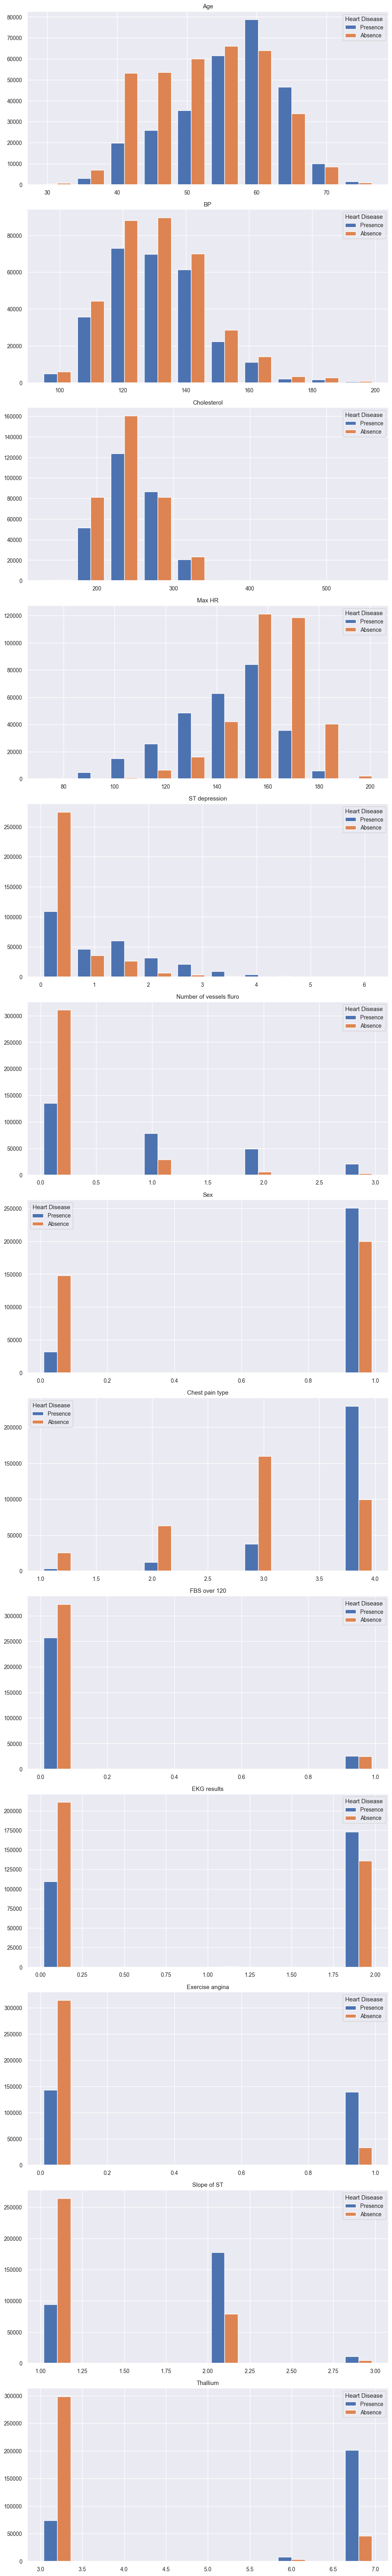

In [35]:
#numerical distributions

fig, axes = plt.subplots(len(features), 1, figsize=(10, 5 * len(features)))

labels = train_df['Heart Disease'].unique()

for i, col in enumerate(train_df[features]):
    grouped = [train_df[train_df['Heart Disease'] == label][col].dropna() for label in labels]
    axes[i].hist(grouped, label=[str(l) for l in labels])
    axes[i].set_title(col)
    axes[i].legend(title='Heart Disease')

plt.tight_layout()
plt.show()

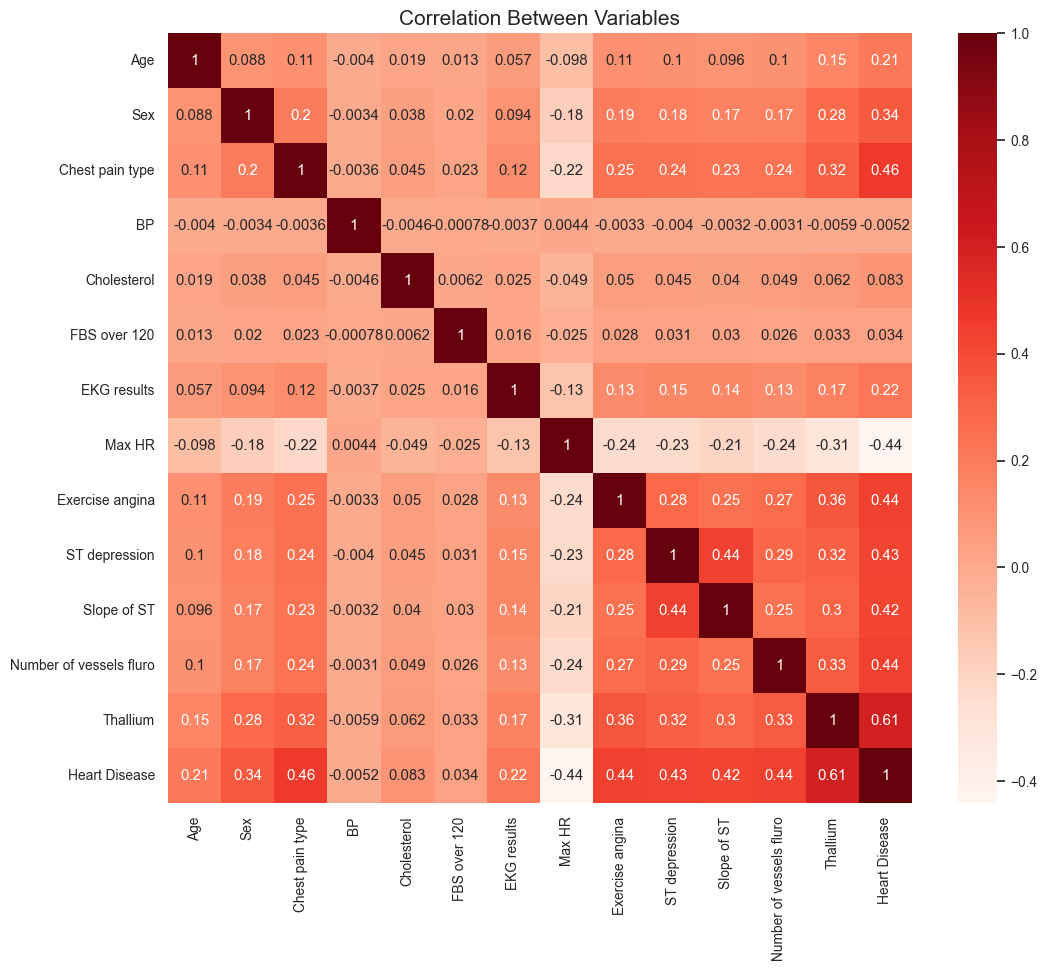

In [36]:
# Correlation heatmap

_train_df = train_df.copy()
_train_df['Heart Disease'] = _train_df['Heart Disease'].apply(lambda x: 1 if x == 'Presence' else 0)
plt.figure(figsize=(12,10))
sns.set(font_scale=0.9)

sns.heatmap(_train_df.corr(),
            annot=True,
            cmap='Reds')

plt.title("Correlation Between Variables", size=15)
plt.show()

In [37]:
# Could be used for potential feature engineering - new score aggregating all of these together
# All show a fairly strong correlation amongst eachother

strong_clustering_feat_1 = [ 'Exercise angina',
                            'ST depression',
                            'Slope of ST',
                            'Number of vessels fluro',
                            'Thallium']

# Potentially could be dropped as showing week correlation
weak_features = ['BP','Cholesterol']

## Preprocessing

In [38]:
# encoding

# categorical encoding
for col in feat_cat:
    train_df[col] = train_df[col].astype(int).astype('category')
    test_df[col] = test_df[col].astype(int).astype('category')  # fix: was incorrectly assigning train_df data

# target encoding
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

train_df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


## Training

In [39]:
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

In [40]:
X = train_df[features]   # input features (all 13 columns)
y = train_df['Heart Disease']  # target (0/1)
X_test = test_df[features]    # test data we'll predict on at the end

In [41]:
def objective(trial):
    params = {
        'n_estimators': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'enable_categorical': True,
        'tree_method': 'hist',
        'early_stopping_rounds': 50,
        'eval_metric': 'auc',
    }
    

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = XGBClassifier(**params, random_state=42)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, preds))

    return np.mean(aucs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(study.best_params)

[I 2026-02-27 22:54:33,412] A new study created in memory with name: no-name-77442f75-d319-4f8a-b0d7-2bb74b74ec15
[I 2026-02-27 22:55:12,624] Trial 0 finished with value: 0.9552609547457123 and parameters: {'learning_rate': 0.058478150879197235, 'max_depth': 4, 'subsample': 0.7765660760741377, 'colsample_bytree': 0.905018475259068, 'reg_alpha': 1.1282257641843252e-05, 'reg_lambda': 3.320906882605293e-07}. Best is trial 0 with value: 0.9552609547457123.
[I 2026-02-27 22:55:51,199] Trial 1 finished with value: 0.9551376727381587 and parameters: {'learning_rate': 0.04427041740026484, 'max_depth': 4, 'subsample': 0.9951252547787266, 'colsample_bytree': 0.6258958458497167, 'reg_alpha': 0.023193432256474883, 'reg_lambda': 0.010412459620172712}. Best is trial 0 with value: 0.9552609547457123.
[I 2026-02-27 22:56:50,885] Trial 2 finished with value: 0.954254416328648 and parameters: {'learning_rate': 0.013165425061173056, 'max_depth': 9, 'subsample': 0.9903839968893708, 'colsample_bytree': 0.9

{'learning_rate': 0.07012684018126353, 'max_depth': 5, 'subsample': 0.964241161031184, 'colsample_bytree': 0.6415324259163926, 'reg_alpha': 5.1850678418264613e-08, 'reg_lambda': 0.0001900763986580939}


In [42]:
study.best_params

{'learning_rate': 0.07012684018126353,
 'max_depth': 5,
 'subsample': 0.964241161031184,
 'colsample_bytree': 0.6415324259163926,
 'reg_alpha': 5.1850678418264613e-08,
 'reg_lambda': 0.0001900763986580939}

In [43]:
#final model with the optimised parameters
final_model = XGBClassifier(
    **study.best_params,
    n_estimators=300,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
)

#fitting model
final_model.fit(X, y)

#prediction
test_preds_p = final_model.predict_proba(X_test)[:, 1]
test_preds = final_model.predict(X_test)


In [44]:
# creating final submission

submission = pd.read_csv(f'data/sample_submission.csv')
submission['Heart Disease'] = test_preds_p
submission.to_csv('data/submission.csv', index=False)

In [45]:
#saving the model

import joblib
joblib.dump(final_model, 'models/model.pkl')



['models/model.pkl']